In [1]:
!pip install bayesian-optimization lightgbm imblearn optbinning probatus 

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import re #regular expression

import matplotlib.pyplot as plt #For plotting graphs
import matplotlib.ticker as mtick
#plt.style.use('ggplot')
#include plots in the notebook
%matplotlib inline 
import seaborn as sns #For plotting graphs
#sns.set(style='darkgrid')
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder #for creating dummy variables out of categorical variables
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, \
confusion_matrix, mean_squared_error, balanced_accuracy_score,roc_curve
import matplotlib.pyplot as plt

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV,RandomizedSearchCV
from scipy.stats import chi2_contingency

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Undersampling and Oversampling Libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss, CondensedNearestNeighbour,TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.metrics import classification_report_imbalanced

from sklearn.preprocessing import OrdinalEncoder

from optbinning import OptimalBinning

# Recursive Feature Elimination
import warnings
# warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
warnings.filterwarnings('ignore')
from probatus.feature_elimination import ShapRFECV

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

#utilities
import collections

import warnings
warnings.filterwarnings("ignore")

# from LGBMBayesianOptimization import bayes_parameter_opt_lgb
from functions import *

import openpyxl

pd.set_option('display.max_colwidth', None)

import shap
# print the JS visualization code to the notebook
shap.initjs()

ModuleNotFoundError: No module named 'lightgbm'

In [3]:
run_date_str = '20231010'
s3_output = f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}' # output directory

# df = pd.read_parquet(f's3://toast-datascience-sandbox/PradeepA/pre90_pd_model/{run_date_str}/processed_train.parquet') 

df_train = pd.read_parquet(os.path.join(s3_output, 'train_xs.parquet'))
df_val =pd.read_parquet(os.path.join(s3_output, 'test_xs.parquet'))

In [4]:
print(df_train.shape)
print(df_val.shape)

(253090, 33)
(60212, 33)


In [5]:
list_us_state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD",
    "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]
df_train = df_train[df_train['state'].isin(list_us_state_codes)]
df_val = df_val[df_val['state'].isin(list_us_state_codes)]

In [6]:
print(df_train.shape)
print(df_val.shape)

(250670, 33)
(58589, 33)


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250670 entries, 3227412 to 85932476
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   rid                              250670 non-null  int64         
 1   dt                               250670 non-null  datetime64[ns]
 2   label_90                         250670 non-null  float64       
 3   state                            250670 non-null  object        
 4   parent_market_segment            250670 non-null  object        
 5   restaurant_type                  250670 non-null  object        
 6   account_restaurant_category      250477 non-null  object        
 7   days_delta_first_obs             250670 non-null  int64         
 8   first_loan_date                  27014 non-null   datetime64[ns]
 9   days_with_toast                  250670 non-null  int64         
 10  months_with_toast                250670 n

In [48]:
df1 = df_train[df_train['days_with_toast']>90]['days_with_toast'].value_counts()
df1.shape

(690,)

In [43]:
df1 = df_train[df_train['days_with_toast'] < 30]['label_90']
df1.shape

(3852,)

In [8]:
print('Not Default vs Default\n',df_train.label_90.value_counts(dropna=False))
var = round(df_train.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    237664
1.0     13006
Name: count, dtype: int64
The event rate is 5.19%


In [9]:
print('Not Default vs Default\n',df_val.label_90.value_counts(dropna=False))
var = round(df_val.label_90.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 label_90
0.0    55500
1.0     3089
Name: count, dtype: int64
The event rate is 5.27%


In [10]:
df_val['dt'].min()

Timestamp('2023-02-21 00:00:00')

# Create seasonality features

In [11]:
df_train['day_of_year'] = df_train['dt'].dt.dayofyear
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_train['month'] = df_train['dt'].dt.month
df_train['quarter'] = df_train['dt'].dt.quarter
df_val['day_of_year'] = df_val['dt'].dt.dayofyear
df_val['month'] = df_val['dt'].dt.month
df_val['quarter'] = df_val['dt'].dt.quarter

# Train/Test Split

In [12]:
data = df_train.copy()
y = data.label_90
remove_list = ['label_90']
stratify_class = data[['label_90', 'state']]
X = data.drop(columns=remove_list)

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=.25, random_state=42)
X_train.shape, X_test.shape

((188002, 35), (62668, 35))

In [13]:
df_train = pd.merge(X_train,y_train,left_index=True,right_index=True,how='inner')
df_test = pd.merge(X_test,y_test,left_index=True,right_index=True,how='inner')

# LGBM variable list preparation

In [14]:
feature_list = [
    'rid', 'dt', 'label_90',
    'state', 'parent_market_segment', 'restaurant_type', 'account_restaurant_category',
    'day_of_year', 'month', 'quarter',
    'first_loan_date', 'days_with_toast', 'months_with_toast', 'first_loan_date_90d',
    'has_oo_mod', 'has_gc_mod', 'noprocessing_last_90d',
    'gpv_mean_90d', 'gpv_mean_28d', 'gpv_median_28d', 'gpv_cv_90d', 'log_gpv_std_90d',
    'gpv_median_28d_mean_90d_diff', 'gpv_median_28d_median_84d_diff',
    'gpv_median_28d_28ddiff', 'gpv_median_28d_84ddiff',
    'gpv_per_hour_median_28d', 'gpv_per_hour_median_28d_28ddiff', 
    'days_no_gpv_90d', 'days_no_gpv_28d', 'days_no_gpv_28d_28ddiff',
    'tx_hours_mean_14d', 'tx_hours_median_14d', 'tx_hours_median_28d', 'tx_hours_median_28d_28ddiff',
]

In [15]:

vars_cat = [
    # 'state',
            'account_restaurant_category',
            'parent_market_segment',
           ]
vars_noorder = ['day_of_year']
vars_asc = ['days_no_gpv_28d',
            'days_no_gpv_90d',
            # 'days_no_gpv_28d_28ddiff',
           'gpv_cv_90d',
            # 'noprocessing_last_90d',
           ]
vars_des =[  'has_gc_mod',
           # 'has_oo_mod',
           'gpv_mean_28d',
           'gpv_mean_90d',
           # 'gpv_median_28d_mean_90d_diff',
           'gpv_median_28d_28ddiff',
           'gpv_per_hour_median_28d',
           'tx_hours_median_14d',
           # 'tx_hours_median_28d',
           'tx_hours_median_28d_28ddiff',
          ]
pd_features = vars_cat + vars_noorder + vars_asc + vars_des
var_monotone = [0] * len(vars_cat + vars_noorder) +[1] * len(vars_asc) + [-1] * len(vars_des)
df_train_encoded = df_train.copy()
df_test_encoded = df_test.copy()
df_val_encoded = df_val.copy()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
df_train_encoded[vars_cat] = oe.fit_transform(df_train_encoded[vars_cat])
df_test_encoded[vars_cat] = oe.fit_transform(df_test_encoded[vars_cat])
df_val_encoded[vars_cat] = oe.fit_transform(df_val_encoded[vars_cat])

In [16]:
df = pd.concat([df_train,df_test,df_val])
df[pd_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 309259 entries, 71753068 to 89426422
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   account_restaurant_category  309066 non-null  object 
 1   parent_market_segment        309259 non-null  object 
 2   day_of_year                  309259 non-null  int32  
 3   days_no_gpv_28d              309259 non-null  float64
 4   days_no_gpv_90d              309259 non-null  float64
 5   gpv_cv_90d                   309259 non-null  float64
 6   has_gc_mod                   309259 non-null  int64  
 7   gpv_mean_28d                 309259 non-null  float64
 8   gpv_mean_90d                 309259 non-null  float64
 9   gpv_median_28d_28ddiff       309259 non-null  float64
 10  gpv_per_hour_median_28d      309259 non-null  float64
 11  tx_hours_median_14d          309259 non-null  float64
 12  tx_hours_median_28d_28ddiff  309259 non-null  float64


In [17]:
model_param = {
        'objective': 'binary',
'verbosity': -1,
'boosting_type': 'gbdt', 'deterministic': True,
'seed': 2022,
'bagging_seed': 2023, 'monotone_constraints': var_monotone, 'learning_rate': 0.1,
        'num_leaves': 31,
        'min_child_samples': 20,
        'n_estimators': 100,
}
model = lgb.LGBMClassifier(importance_type='gain', **model_param)

model.fit(df_train_encoded[pd_features], y_train)

LGBMClassifier(bagging_seed=2023, deterministic=True, importance_type='gain',
               monotone_constraints=[0, 0, 0, 1, 1, 1, -1, -1, -1, -1, -1, -1,
                                     -1],
               objective='binary', seed=2022, verbosity=-1)

In [18]:
# make prediction on the trainin and test set
df_train_encoded['y_pred'] = model.predict_proba(df_train_encoded[pd_features])[:,1] 
print(f"training set AUC: {roc_auc_score(y_train, df_train_encoded['y_pred']).round(3)}")

df_test_encoded['y_pred'] = model.predict_proba(df_test_encoded[pd_features])[:,1] 
print(f"test set AUC: {roc_auc_score(y_test, df_test_encoded['y_pred']).round (3)}")

df_val_encoded['y_pred'] = model.predict_proba(df_val_encoded[pd_features])[:,1] 
print(f"Val set AUC: {roc_auc_score(df_val['label_90'], df_val_encoded['y_pred']).round (3)}")

training set AUC: 0.887
test set AUC: 0.867
Val set AUC: 0.865


In [19]:
def exp_vs_act(df,score,target,title_text = None):
    
    df[score] = round(df[score],3)
    
    #print(df.info())
    orig_feature = score
    
    #CREATE THE SUMMARY TABLE
    if str(df[orig_feature].dtype) !='object':
        grp_range = 'grp_' + score
        df[grp_range] = pd.qcut(df[score], q=10, labels=None, retbins = False,  duplicates = 'raise')
        df['grp_num'] = (pd.qcut(df[score], q=10, labels=False, retbins = False,  duplicates = 'raise')+1).astype(str).str.zfill(2)
        df['grp'] = df['grp_num'].astype(str) + ' ' +df[grp_range].astype(str)
        score = 'grp'
        
    non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
    events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left",on=score)
    
    if str(df[orig_feature].dtype) !='object':
        pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
        result = pd.merge(result, pred_events, how="left",on=score)
        
    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events']/result['total'],3)
    if str(df[orig_feature].dtype) !='object':
        result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
    result['% event dist'] = result['events']/(events_total.values)
    result['% non-event dist'] = result['non_events']/(non_events_total.values)
    result['% total dist'] = round(result['total']/grand_total*100,1)
    cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
    result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
    result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

    # Calculate IV
    IV = round(result.IV.sum(),6)
    #print('Information Value of',"'"+score+"'",'is', IV)
    
    #round off the decimal places for better display
    result['% event dist'] = round(result['% event dist']*100,1)
    result['% non-event dist'] = round(result['% non-event dist']*100,1)
    result['WoE'] = round(result['WoE'],2)
    result['IV'] = round(result['IV'],2) 
    
    # convert index (score) to column
    result.reset_index(inplace=True)
    
    # Replace nan with Missing
    result[score]=result[score].replace(np.nan, 'Missing', regex=True)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax = result.plot(x='grp', y=['act_event_rate','pred_event_rate'],color=['red', 'blue'],marker="*",title=title_text,ax=ax)
    ax.set_xticks(range(len(result)))
    
    p = ax.set_xticklabels([item for item in result.grp.tolist()],rotation=45)
    
    return result

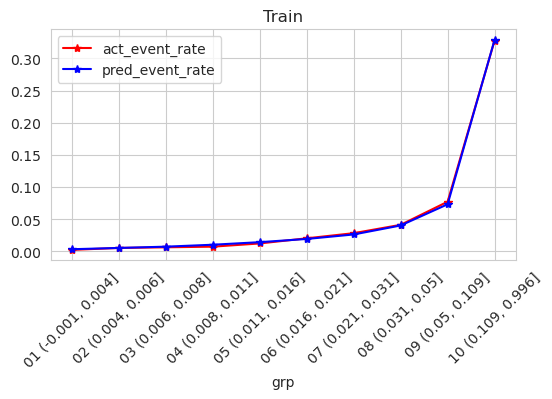

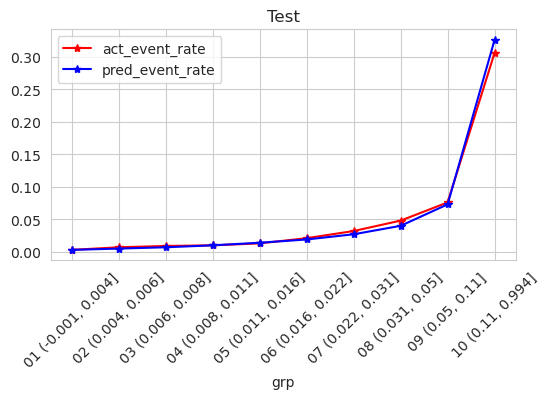

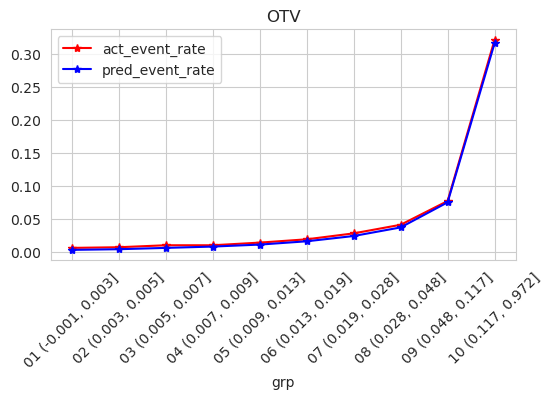

In [20]:
ror_train = exp_vs_act(df_train_encoded,'y_pred','label_90','Train')
ror_test = exp_vs_act(df_test_encoded,'y_pred','label_90','Test')
ror_val = exp_vs_act(df_val_encoded,'y_pred','label_90','OTV')

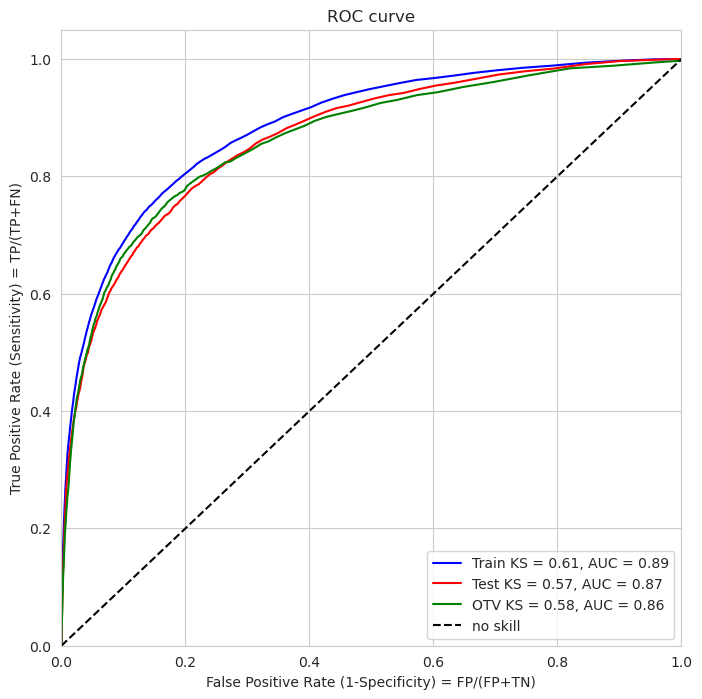

In [21]:
# from functions import plot_auc3
fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
# plot_auc2(ax, y_train, df_train['y_pred'], y_test, df_test['y_pred'])
plot_auc3(ax, y_train, df_train_encoded['y_pred'], y_test, df_test_encoded['y_pred'], df_val_encoded.label_90, df_val_encoded['y_pred'])

100%|===================| 58371/58589 [02:41<00:00]        

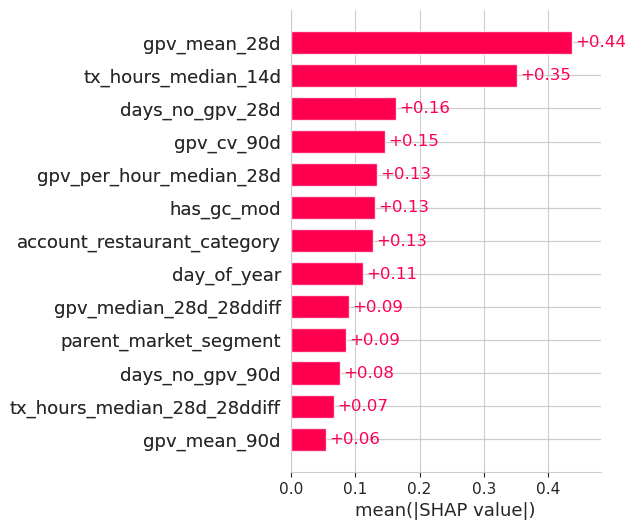

In [22]:
explainer = shap.Explainer(model, df_val_encoded[pd_features], feature_names=[pd_features])
shap_values = explainer(df_val_encoded[pd_features],check_additivity=False)
fig = plt.figure()
shap.plots.bar(shap_values, max_display=20,show = False)
plt.gcf().set_size_inches(4,6)
plt.show()

In [23]:
feature_names = shap_values.feature_names
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
vals = np.abs(shap_df.values).mean(0)
shap_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name', 'feature_importance_vals'])
shap_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)

In [24]:
shap_importance

,col_name,feature_importance_vals
7,gpv_mean_28d,0.436532
11,tx_hours_median_14d,0.350602
3,days_no_gpv_28d,0.164003
5,gpv_cv_90d,0.146700
10,gpv_per_hour_median_28d,0.134400
6,has_gc_mod,0.131357
0,account_restaurant_category,0.128234
2,day_of_year,0.112895
9,gpv_median_28d_28ddiff,0.090853
1,parent_market_segment,0.085347


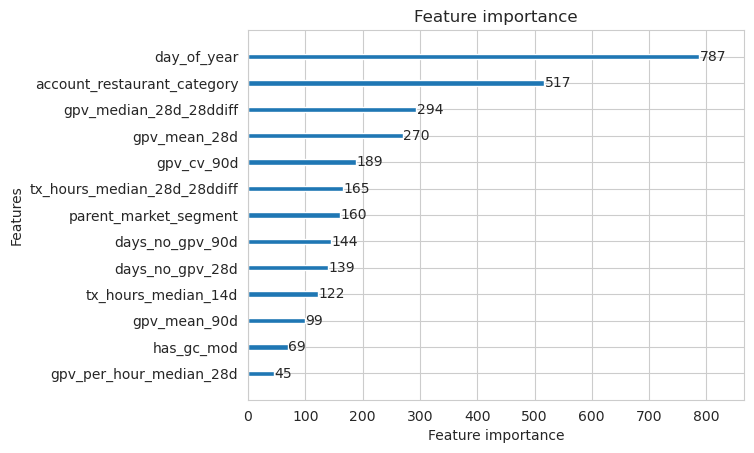

In [25]:
# Plot feature importance
lgb.plot_importance(model, importance_type='split', max_num_features=20)  # You can adjust max_num_features as needed
plt.show()

In [26]:
df_train_encoded['yyyymm'] = df_train_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_test_encoded['yyyymm'] = df_test_encoded['dt'].astype(str).str[:7].str.replace('-', '')
df_val_encoded['yyyymm'] = df_val_encoded['dt'].astype(str).str[:7].str.replace('-', '')

In [27]:
df_train_encoded['yyyymm'].dtype

dtype('O')

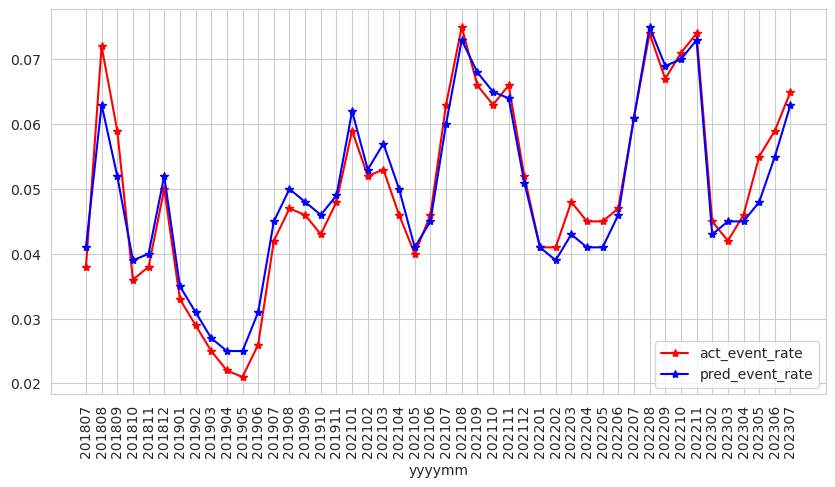

In [28]:
df = pd.concat([df_train_encoded,df_test_encoded,df_val_encoded])
target = 'label_90'

orig_feature = 'y_pred'

score = 'yyyymm'
non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
grand_total = df[target].count()
result = pd.merge(non_events, events, how="left",on=score)

if str(df[orig_feature].dtype) !='object':
    pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
    result = pd.merge(result, pred_events, how="left",on=score)

result['total'] = result['non_events'] + result['events']
result['act_event_rate'] = round(result['events']/result['total'],3)
if str(df[orig_feature].dtype) !='object':
    result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
result['% event dist'] = result['events']/(events_total.values)
result['% non-event dist'] = result['non_events']/(non_events_total.values)
result['% total dist'] = round(result['total']/grand_total*100,1)
cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

# Calculate IV
IV = round(result.IV.sum(),6)
#print('Information Value of',"'"+score+"'",'is', IV)

#round off the decimal places for better display
result['% event dist'] = round(result['% event dist']*100,1)
result['% non-event dist'] = round(result['% non-event dist']*100,1)
result['WoE'] = round(result['WoE'],2)

# convert index (score) to column
result.reset_index(inplace=True)

# Replace nan with Missing
result[score]=result[score].replace(np.nan, 'Missing', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))

result.plot(x=score, y=['act_event_rate','pred_event_rate'],color=['red', 'blue'],marker="*",ax=ax)
ax.set_xticks(range(len(result)))
p=ax.set_xticklabels([item for item in result.yyyymm.tolist()],rotation=90)

In [29]:
print(f"AUC: {roc_auc_score(df_val_encoded['label_90'], df_val_encoded['y_pred']).round (3)}")
print()
print('Difference between average prediction and true default rate')
print(f"Diff in mean pred: {(df_val_encoded['y_pred'].mean() - df_val_encoded['label_90'].mean()).round(3)}")
print(f"Diff in std pred: {(df_val_encoded['y_pred'].std() - df_val_encoded['label_90'].std())}")

AUC: 0.865

Difference between average prediction and true default rate
Diff in mean pred: -0.003
Diff in std pred: -0.11545395733685479


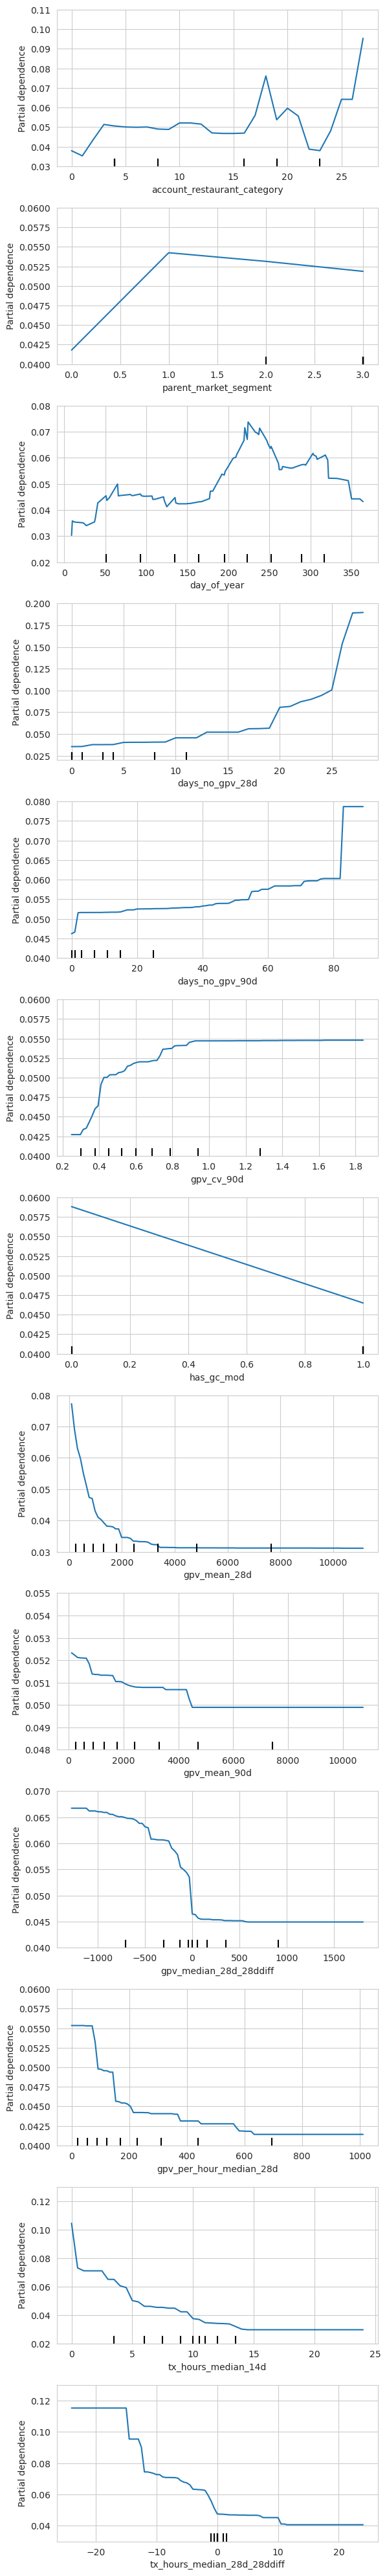

In [30]:
from sklearn.inspection import (partial_dependence, PartialDependenceDisplay)
n_cols = 1
n_rows = int(len(df_train_encoded[pd_features].columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(6, 40))
tree_disp = PartialDependenceDisplay.from_estimator(model, df_train_encoded[pd_features], df_train_encoded[pd_features].columns, ax=ax, n_cols=n_cols)
tree_disp.axes_[0].set_ylim(0.03,.11)
tree_disp.axes_[1].set_ylim(0.04,.06)
tree_disp.axes_[2].set_ylim(0.02,.08)
tree_disp.axes_[3].set_ylim(0.02,.2)
tree_disp.axes_[4].set_ylim(0.04,.08)
tree_disp.axes_[5].set_ylim(0.04,.06)
tree_disp.axes_[6].set_ylim(0.04,.06)
tree_disp.axes_[7].set_ylim(0.03,.08)
tree_disp.axes_[8].set_ylim(0.048,.055)
tree_disp.axes_[9].set_ylim(0.04,.07)
tree_disp.axes_[10].set_ylim(0.04,.06)
tree_disp.axes_[11].set_ylim(0.02,.13)
tree_disp.axes_[12].set_ylim(0.03,.13)
fig.suptitle('')
fig.tight_layout()